# 3D-Ironing: quasistarrer Würfel auf elastischem Block

Nach **Popp, Gitterle, Gee & Wall (2010), Abschnitt 8.2, Würfelvariante in Abb. 11**, [DOI: 10.1002/nme.2866](https://doi.org/10.1002/nme.2866), [lokales Paper](../A%20dual%20mortar%20approach%20for%203D%20f%20-%20Alexander%20Popp.pdf).

Der Würfel hat Kantenlänge **1**, der Block Abmessungen **9 × 4 × 3**. Beide Körper sind kompressibel neo-Hookesch mit $E_\mathrm{Würfel}=1000$, $E_\mathrm{Block}=1$, $\nu=0.3$. Zuerst wird die Würfeloberseite um **1.4** eingedrückt, dann bei konstanter Eindrückung um **4.0** in $+x$ verschoben. Der Würfel bleibt ein deformierbarer Körper mit hoher Steifigkeit.

Die Koordinate $z$ zeigt hier **nach oben**: $u_z=-w$. Als explizite Modellannahmen wird der Blockboden vollständig fixiert und der Würfel anfangs bei $(x,y)=(2.5,2)$ zentriert; die übrigen Blockflächen sind frei. Auf der Würfeloberseite sind alle drei Komponenten vorgegeben: $(u_x,u_y,u_z)=(u,0,-w)$. Das Paper spezifiziert diese Anfangslage und die Lagerdetails im Text von 8.2 nicht vollständig.

Verwendet wird der **3D-Gaußpunkt-zu-Dreieck-Penalty-Kontakt aus `contact_finite_strain_3d.ipynb` / `contact_hertz_3d.ipynb`**, basierend auf [Fischer & Wriggers (2005)](https://doi.org/10.1007/s00466-005-0660-y): aktuelle Projektion, Flächenänderung, analytische konsistente Tangente und Kanten-/Eckprojektion. Dies ist eine Umsetzung des Benchmark-Lastfalls mit den vorhandenen Kontaktalgorithmen, keine Reimplementierung des Dual-Mortar-Verfahrens. Die Blockoberseite ist Slave; die **Würfelunterseite und die vier Seitenflächen** ist Master. Die belastete Oberseite gehört nicht zur Kontaktfläche. Dadurch werden auch die Seiten und Kanten beim Gleiten berücksichtigt; die orientierte offene Masterfläche verhindert eine falsche Freigabe beim vollständigen Eintauchen. Die Projektion auf den steifen Körper vermeidet eine facettenweise Suche auf der stark eingedrückten Blockmulde.

Alle Elemente sind T4. Jede Slavefläche wird für die Kontaktintegration in vier Teildreiecke mit je drei Gaußpunkten zerlegt (12 Punkte je FE-Fläche). Einheitenkonvention: mm, MPa, N. DOLFINx 0.11, reelles PETSc, ein MPI-Rang. Das Notebook ist eigenständig ausführbar; es liest weder Code noch Ergebnisse anderer Notebooks. Die Kräfte werden unmittelbar aus den konvergierten FEM-Residuen berechnet.


In [1]:
from pathlib import Path
from itertools import permutations
import json

import numpy as np
import basix.ufl
import ufl
import dolfinx
import dolfinx.fem.petsc
from mpi4py import MPI
from petsc4py import PETSc
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

comm = MPI.COMM_WORLD
if comm.size != 1:
    raise RuntimeError("Die explizite Kontaktassemblierung benötigt einen MPI-Rang.")
if np.issubdtype(PETSc.ScalarType, np.complexfloating):
    raise RuntimeError("Ein reeller PETSc-Build wird benötigt.")

# Geometrie und Material (Popp et al., Abschnitt 8.2 / Abb. 8 und 11).
block_length, block_width, block_height = 9.0, 4.0, 3.0
cube_edge = 1.0
cube_center = np.array([2.5, 2.0])
E_cube, E_block, nu = 1000.0, 1.0, 0.3
CUBE, BLOCK = 1, 2
CUBE_CONTACT, CUBE_TOP, BASE_BOTTOM, BASE_TOP = 3, 4, 5, 6
gdim, tdim, fdim = 3, 3, 2
element = ("Lagrange", 1, (3,))
# Verfeinerung hier einstellen; das voreingestellte Netz ist eine Demonstration,
# keine netzkonvergierte Referenzkurve.
n_block_x, n_block_y, n_block_z = 24, 12, 8
n_cube = 4
size_min = min(block_length/n_block_x, block_width/n_block_y,
               block_height/n_block_z, cube_edge/n_cube)
penalty_factor = 100.0
penalty_eps = penalty_factor * E_block / size_min  # N/mm³
assert min(n_block_x, n_block_y, n_block_z, n_cube) > 0
gauss_N = np.array([[2/3, 1/6, 1/6], [1/6, 2/3, 1/6], [1/6, 1/6, 2/3]])
# Zusammengesetzte Dreipunktregel: feinere Kontaktintegration ohne zusätzliche FE-DOFs.
contact_subdivisions = 2
subtriangles = []
for i in range(contact_subdivisions):
    for j in range(contact_subdivisions-i):
        subtriangles.append(np.array([[i,j], [i+1,j], [i,j+1]])/contact_subdivisions)
        if i+j < contact_subdivisions-1:
            subtriangles.append(np.array([[i+1,j], [i+1,j+1], [i,j+1]])/contact_subdivisions)
gauss_N = np.vstack([gauss_N @ np.column_stack((1-t.sum(axis=1), t)) for t in subtriangles])
gauss_w = np.full(len(gauss_N), 1/(6*contact_subdivisions**2))
num_gauss = len(gauss_N)
indentation_goal, sliding_goal = 1.4, 4.0
# Etwa 100 XDMF-Ausgaben: 100 Intervalle plus Anfangszustand.
# Beide Lastphasen erhalten annähernd gleiche Abstände im Pfadparameter s.
n_output_intervals = 100
assert isinstance(n_output_intervals, int) and n_output_intervals >= 2
n_indent_outputs = max(1, min(n_output_intervals-1,
    round(n_output_intervals*indentation_goal/(indentation_goal+sliding_goal))))
output_targets = np.r_[np.linspace(0, indentation_goal, n_indent_outputs+1),
    np.linspace(indentation_goal, indentation_goal+sliding_goal,
                n_output_intervals-n_indent_outputs+1)[1:]]
assert len(output_targets) == n_output_intervals+1
initial_increment, max_increment, min_increment = 0.035, 0.07, 0.0001
max_newton, max_contact_iter, max_backtracks = 60, 40, 24
active_set_mode = "newton"  # "outer": ursprüngliche äußere Kontaktiteration
assert active_set_mode in ("newton", "outer")
force_tolerance = 1e-7
detF_floor = 1e-8
verbose_newton = False
results = Path("results_ironing_cube_100_work")
results.mkdir(exist_ok=True)
print(f"DOLFINx {dolfinx.__version__}; epsilon_N={penalty_eps:g} N/mm³")

# Vorhandenen Checkpoint automatisch prüfen und fortsetzen; ohne Datei neu starten.
# Für eine vollständige Neuberechnung False setzen.
resume_from_checkpoint = (results / "checkpoint.npz").is_file()
run_signature = json.dumps(dict(
    formulation="ironing-open-master-current-area-v1",
    geometry=[block_length, block_width, block_height, cube_edge, *cube_center.tolist()],
    material=[E_cube, E_block, nu],
    mesh=[n_block_x, n_block_y, n_block_z, n_cube],
    penalty=penalty_eps, quadrature=contact_subdivisions,
    goals=[indentation_goal, sliding_goal], active_set_mode=active_set_mode,
    force_tolerance=force_tolerance, output_intervals=n_output_intervals), sort_keys=True)


DOLFINx 0.11.0.post0; epsilon_N=400 N/mm³


## Getrennte Körpernetze und Randflächen

Ein strukturiertes Gitter wird konform in sechs Tetraeder je Zelle zerlegt. Würfel und Block haben auch an der anfänglichen Berührfläche unabhängige Knoten. Die Kontaktflächen werden über Materialzugehörigkeit und Referenzkoordinaten markiert.

In [2]:
def grid_tetrahedra(shape, offset=0):
    """Konforme Zerlegung aller Parameterzellen entlang der (0,0,0)-(1,1,1)-Diagonale."""
    indices = np.arange(np.prod(shape)).reshape(shape) + offset
    tetrahedra, parameter_cells = [], []
    for i in range(shape[0] - 1):
        for j in range(shape[1] - 1):
            for k in range(shape[2] - 1):
                for order in permutations(range(3)):
                    local = np.array([i, j, k])
                    tet = [indices[tuple(local)]]
                    for axis in order:
                        local[axis] += 1
                        tet.append(indices[tuple(local)])
                    tetrahedra.append(tet)
                    parameter_cells.append((i, j, k))
    return np.asarray(tetrahedra, dtype=np.int64), np.asarray(parameter_cells)


def box_grid(lower, upper, counts, offset=0):
    axes = [np.linspace(a, b, n+1) for a, b, n in zip(lower, upper, counts)]
    grid = np.meshgrid(*axes, indexing="ij")
    points = np.column_stack([g.ravel() for g in grid])
    tets, _ = grid_tetrahedra(grid[0].shape, offset)
    return points, tets

cube_lower = np.r_[cube_center - cube_edge/2, 0.0]
cube_upper = np.r_[cube_center + cube_edge/2, cube_edge]
cube_coordinates, cube_tets = box_grid(cube_lower, cube_upper, [n_cube]*3)
base_coordinates, base_tets = box_grid([0, 0, -block_height],
    [block_length, block_width, 0], [n_block_x, n_block_y, n_block_z], len(cube_coordinates))
coordinates = np.vstack((cube_coordinates, base_coordinates))
tetrahedra = np.vstack((cube_tets, base_tets))
input_material = np.r_[np.full(len(cube_tets), CUBE), np.full(len(base_tets), BLOCK)].astype(np.int32)
edges = coordinates[tetrahedra[:, 1:]] - coordinates[tetrahedra[:, :1]]
signed_det = np.linalg.det(edges)
assert np.all(np.abs(signed_det) > 1e-12)
reverse = signed_det < 0
tetrahedra[reverse, 1], tetrahedra[reverse, 2] = tetrahedra[reverse, 2].copy(), tetrahedra[reverse, 1].copy()

coordinate_element = basix.ufl.element("Lagrange", "tetrahedron", 1, shape=(3,))
domain = dolfinx.mesh.create_mesh(comm, tetrahedra, ufl.Mesh(coordinate_element), coordinates)
assert domain.topology.cell_type == dolfinx.mesh.CellType.tetrahedron
for d0, d1 in ((tdim, 0), (0, tdim), (fdim, 0), (fdim, tdim)):
    domain.topology.create_connectivity(d0, d1)
cell_indices = np.arange(domain.topology.index_map(tdim).size_local, dtype=np.int32)
original_cells = domain.topology.original_cell_index
cell_tags = dolfinx.mesh.meshtags(domain, tdim, cell_indices, input_material[original_cells])
facets2vertices = domain.topology.connectivity(fdim, 0)
facets2cells = domain.topology.connectivity(fdim, tdim)
cells2vertices = domain.topology.connectivity(tdim, 0)

exterior = dolfinx.mesh.exterior_facet_indices(domain.topology)
geometry_facets = dolfinx.mesh.entities_to_geometry(domain, fdim, exterior)
facet_coordinates = domain.geometry.x[geometry_facets]
adjacent_cells = np.array([facets2cells.links(f).item() for f in exterior])
adjacent_material = cell_tags.values[adjacent_cells]
facet_values = np.zeros(len(exterior), dtype=np.int32)
is_cube, is_block = adjacent_material == CUBE, adjacent_material == BLOCK
on_cube_top = is_cube & np.all(np.isclose(facet_coordinates[:, :, 2], cube_edge), axis=1)
on_base_top = is_block & np.all(np.isclose(facet_coordinates[:, :, 2], 0), axis=1)
on_bottom = is_block & np.all(np.isclose(facet_coordinates[:, :, 2], -block_height), axis=1)
facet_values[is_cube & ~on_cube_top] = CUBE_CONTACT
facet_values[on_cube_top] = CUBE_TOP
facet_values[on_base_top], facet_values[on_bottom] = BASE_TOP, BASE_BOTTOM
marked = facet_values != 0
facet_tags = dolfinx.mesh.meshtags(domain, fdim, exterior[marked], facet_values[marked])
slave_facets = facet_tags.find(BASE_TOP)
master_facets = facet_tags.find(CUBE_CONTACT)
assert len(slave_facets) == 2*n_block_x*n_block_y
assert len(master_facets) == 10*n_cube**2
print(f"{len(cell_indices)} T4, {len(slave_facets)} Slave- und {len(master_facets)} Master-Dreiecke")


14208 T4, 576 Slave- und 160 Master-Dreiecke


In [3]:
V = dolfinx.fem.functionspace(domain, element)
uh = dolfinx.fem.Function(V, name="u")
du = dolfinx.fem.Function(V)
v, du_trial = ufl.TestFunction(V), ufl.TrialFunction(V)
assert V.dofmap.index_map_bs == 3 and V.dofmap.bs == 3
X = V.tabulate_dof_coordinates().copy()  # Positionen in Verschiebungsblock-Reihenfolge
x_current = X.copy()

# Topologie-, Geometrie- und Verschiebungsindizes sind nicht austauschbar.
# Lokale Zuordnung im Tetraeder vermeidet auch Verwechslung der anfänglichen Berührlinie.
nvertices = domain.topology.index_map(0).size_local
vertex_geometry = dolfinx.mesh.entities_to_geometry(
    domain, 0, np.arange(nvertices, dtype=np.int32)
).ravel()
vertex_block = np.full(nvertices, -1, dtype=np.int32)
cell_blocks = np.empty((len(cell_indices), 4), dtype=np.int32)
for cell in cell_indices:
    vertices = cells2vertices.links(cell)
    blocks = V.dofmap.cell_dofs(cell)
    assert len(blocks) == 4
    coordinates = domain.geometry.x[vertex_geometry[vertices]]
    distance2 = np.sum((coordinates[:, None, :] - X[blocks][None, :, :])**2, axis=2)
    local = np.argmin(distance2, axis=1)
    assert len(np.unique(local)) == 4 and np.max(distance2[np.arange(4), local]) < 1e-22
    mapped = blocks[local]
    assert np.all((vertex_block[vertices] < 0) | (vertex_block[vertices] == mapped))
    vertex_block[vertices] = mapped
    cell_blocks[cell] = mapped
assert np.all(vertex_block >= 0)


def boundary_triangles(facets):
    triangles, adjacent = [], []
    for facet in facets:
        nodes = vertex_block[facets2vertices.links(facet)].copy()
        cells = facets2cells.links(facet)
        assert len(nodes) == 3 and len(cells) == 1
        cell = int(cells[0])
        a, b, c = X[nodes]
        # Nach außen orientieren; Orientierung bleibt für det(F)>0 erhalten.
        if np.dot(np.cross(b - a, c - a), X[cell_blocks[cell]].mean(axis=0) - a) > 0:
            nodes[[1, 2]] = nodes[[2, 1]]
        triangles.append(nodes)
        adjacent.append(cell)
    return np.asarray(triangles, dtype=np.int32), np.asarray(adjacent, dtype=np.int32)


slave_nodes, slave_cells = boundary_triangles(slave_facets)
master_nodes, master_cells = boundary_triangles(master_facets)


U_x = dolfinx.fem.Constant(domain, PETSc.ScalarType(0))
U_z = dolfinx.fem.Constant(domain, PETSc.ScalarType(0))


def component_bc(tag, component, value):
    dofs = dolfinx.fem.locate_dofs_topological(V.sub(component), fdim, facet_tags.find(tag))
    return dolfinx.fem.dirichletbc(value, dofs, V.sub(component)), dofs

cube_bc_data = [component_bc(CUBE_TOP, i, value)
               for i, value in enumerate((U_x, PETSc.ScalarType(0), U_z))]
bottom_bc_data = [component_bc(BASE_BOTTOM, i, PETSc.ScalarType(0)) for i in range(3)]
cube_dofs = [dofs for _, dofs in cube_bc_data]
bottom_dofs = [dofs for _, dofs in bottom_bc_data]
bcs = [bc for bc, _ in cube_bc_data + bottom_bc_data]
bc_dofs = np.unique(np.concatenate([bc.dof_indices()[0] for bc in bcs])).astype(PETSc.IntType)
free_dofs = np.setdiff1d(np.arange(len(uh.x.array)), bc_dofs)
cube_blocks = np.unique(cell_blocks[cell_tags.values == CUBE])
base_blocks = np.unique(cell_blocks[cell_tags.values == BLOCK])

def neo_hookean_energy(F_def, E, nu):
    mu, kappa = E / (2 * (1 + nu)), E / (3 * (1 - 2 * nu))
    J_def = ufl.det(F_def)
    return .5 * mu * (J_def**(-2/3) * ufl.inner(F_def, F_def) - 3) + .5 * kappa * (J_def - 1)**2


dx = ufl.Measure("dx", domain=domain, subdomain_data=cell_tags, metadata={"quadrature_degree": 2})
F_def = ufl.variable(ufl.Identity(3) + ufl.grad(uh))
energies = [neo_hookean_energy(F_def, E, nu) for E in (E_cube, E_block)]
Pi_bulk = sum(psi * dx(tag) for psi, tag in zip(energies, (CUBE, BLOCK)))
R_bulk = ufl.derivative(Pi_bulk, uh, v)
K_bulk = ufl.derivative(R_bulk, uh, du_trial)
Pi_form = dolfinx.fem.form(Pi_bulk)
R_form, K_form = dolfinx.fem.form(R_bulk), dolfinx.fem.form(K_bulk)
detF_expression = dolfinx.fem.Expression(ufl.det(F_def), np.array([[.25, .25, .25]]))


def min_detF():
    return float(np.min(detF_expression.eval(domain, cell_indices)))


def impose_bcs():
    for bc in bcs:
        bc.set(uh.x.array)


print(f"{len(uh.x.array)} Freiheitsgrade, davon {len(free_dofs)} frei")

9150 Freiheitsgrade, davon 8100 frei


## Kontaktpotential und konsistente Tangente

Für einen Slave-Gaußpunkt mit festen baryzentrischen Koordinaten $N_s$ sei
$\mathbf r=\mathbf x_s-\mathbf x_m(\boldsymbol\xi)$ der Vektor zum nächsten
Punkt des aktuellen Master-Dreiecks. Im Flächeninneren ist
$g_N=\mathbf r\cdot\mathbf n_m$. Bei Kanten-/Eckpunktprojektion verwenden wir,
wie bei den Endpunkten im 2D-Notebook, den vorzeichenbehafteten Abstand
$g_N=\mathrm{sign}(\mathbf r\cdot\mathbf n_m)\|\mathbf r\|$.
Das ist eine stückweise glatte Erweiterung auf die diskrete Oberfläche;
an Feature-Wechseln existiert keine eindeutige klassische zweite Ableitung.

Auf einem aktiven Zweig ($g_N\leq0$) setzen wir
$\phi=\tfrac12\|\mathbf r\|^2$ und
$j_s=\|(\mathbf x_{s2}-\mathbf x_{s1})\times(\mathbf x_{s3}-\mathbf x_{s1})\|$.
Damit gilt pro Gaußpunkt mit $w=1/(6n_\mathrm{sub}^2)$ bei der zusammengesetzten Dreipunktregel:

$$\Pi_c=w\epsilon_N j_s\phi,\qquad
\mathbf R_c=w\epsilon_N(j_s\mathbf D+\phi\mathbf L),$$
$$\mathbf K_c=w\epsilon_N\left[
j_s\mathbf H_\phi+\mathbf D\otimes\mathbf L+
\mathbf L\otimes\mathbf D+\phi\mathbf H_j\right],$$

wobei $\mathbf D=\partial\phi/\partial\mathbf q$,
$\mathbf L=\partial j_s/\partial\mathbf q$ und die beiden $\mathbf H$ die
zugehörigen Hesse-Matrizen bezüglich der 18 lokalen Freiheitsgrade sind.
**Alle Flächenvariationen bleiben erhalten**, einschließlich $\mathbf H_j$.

Die Projektionskoordinaten werden analytisch eliminiert. Mit
$\mathbf H=[N_s\otimes\mathbf I,-N_m\otimes\mathbf I]$,
Master-Tangenten $\mathbf A=[\mathbf a_1,\mathbf a_2]$ und
$\mathbf B_\alpha=\partial\mathbf a_\alpha/\partial\mathbf q$ folgt aus der
Stationarität der Abstandsfunktion:

$$\mathbf D=\mathbf H^T\mathbf r,\qquad
\mathbf H_\phi=\mathbf H^T\mathbf H-
\mathbf C^T(\mathbf A^T\mathbf A)^{-1}\mathbf C,\qquad
\mathbf C_\alpha=\mathbf a_\alpha^T\mathbf H+\mathbf r^T\mathbf B_\alpha.$$

Im Flächeninneren werden zwei Koordinaten eliminiert, auf einer Kante eine,
an einem Eckpunkt keine. Das Schur-Komplement enthält die Ableitungen der
gleitenden Projektion und der Normalen; es werden keine Projektionskoordinaten
in der Tangente eingefroren. Dies ist eine analytische Ableitung, keine
numerische Differentiation im Solver. Zentrale Differenzen dienen unten nur
der unabhängigen Prüfung.

Für die orientierte Würfelkontaktfläche wird das **Vorzeichen** des Abstandes an
Kanten mit der Summe der benachbarten Flächennormalen und an Ecken mit
winkelgewichteten Knotennormalen bestimmt. So bleiben seitlich außerhalb des
Würfels liegende Punkte auch dann kontaktfrei, wenn ihr Abstand tangential zu einer einzelnen
Nachbarfläche liegt. Abstandsbetrag, Kontaktpotential und analytische Tangente
bleiben unverändert; die Pseudonormale dient ausschließlich der Aktivitätsprüfung. Am offenen oberen Rand wird die Normale der angrenzenden Seitenfläche verwendet. Die Kontaktfläche wird damit als undurchdringliche, orientierte Werkzeugfläche interpretiert; die Antriebsfläche ist keine mögliche Austrittsfläche für den Block.


In [4]:
def closest_on_triangles(point, triangles):
    """Exaktes Minimum auf jedem geschlossenen Dreieck: Fläche oder drei Kanten."""
    a = triangles[:, 0]
    e1, e2 = triangles[:, 1] - a, triangles[:, 2] - a
    d = point - a
    g11 = np.einsum("ij,ij->i", e1, e1)
    g12 = np.einsum("ij,ij->i", e1, e2)
    g22 = np.einsum("ij,ij->i", e2, e2)
    b1 = np.einsum("ij,ij->i", e1, d)
    b2 = np.einsum("ij,ij->i", e2, d)
    determinant = g11 * g22 - g12**2
    if np.any(determinant <= 0):
        raise RuntimeError("Degeneriertes Master-Dreieck")
    xi = (g22 * b1 - g12 * b2) / determinant
    eta = (g11 * b2 - g12 * b1) / determinant
    N = np.stack((1 - xi - eta, xi, eta), axis=1)
    projected = np.einsum("ni,nij->nj", N, triangles)
    distance2 = np.sum((point - projected)**2, axis=1)
    distance2[np.any(N < 0.0, axis=1)] = np.inf
    for i, j in ((0, 1), (1, 2), (2, 0)):
        edge = triangles[:, j] - triangles[:, i]
        t = np.clip(np.einsum("ij,ij->i", point - triangles[:, i], edge)
                    / np.einsum("ij,ij->i", edge, edge), 0.0, 1.0)
        edge_point = triangles[:, i] + t[:, None] * edge
        edge_dist2 = np.sum((point - edge_point)**2, axis=1)
        better = edge_dist2 < distance2
        N[better] = 0.0
        N[better, i], N[better, j] = 1 - t[better], t[better]
        distance2[better] = edge_dist2[better]
    return N, distance2



def closest_many(points, triangles, batch_size=128):
    """Exakte nächste Punkte auf ALLEN aktuellen Master-Dreiecken.

    Blockweise Vektorisierung begrenzt den Speicher; es gibt keinen Suchradius,
    der bei großem Gleiten Kontakt verlieren könnte.
    """
    a = triangles[:, 0]
    e1, e2 = triangles[:, 1] - a, triangles[:, 2] - a
    g11, g12, g22 = np.sum(e1*e1, axis=1), np.sum(e1*e2, axis=1), np.sum(e2*e2, axis=1)
    det = g11 * g22 - g12**2
    if np.any(det <= 0):
        raise RuntimeError("Degeneriertes Master-Dreieck")
    master_ids = np.empty(len(points), dtype=np.int32)
    master_weights = np.empty((len(points), 3))
    for start in range(0, len(points), batch_size):
        queries = points[start:start+batch_size]
        d = queries[:, None, :] - a
        b1, b2 = np.einsum("pmi,mi->pm", d, e1), np.einsum("pmi,mi->pm", d, e2)
        xi, eta = (g22*b1-g12*b2)/det, (g11*b2-g12*b1)/det
        N = np.stack((1-xi-eta, xi, eta), axis=2)
        r = d - xi[:, :, None]*e1 - eta[:, :, None]*e2
        distance2 = np.sum(r*r, axis=2)
        distance2[np.any(N < 0, axis=2)] = np.inf
        for i, j in ((0, 1), (1, 2), (2, 0)):
            edge = triangles[:, j] - triangles[:, i]
            to_point = queries[:, None, :] - triangles[:, i]
            t = np.clip(np.einsum("pmi,mi->pm", to_point, edge) / np.sum(edge*edge, axis=1), 0, 1)
            r = to_point - t[:, :, None]*edge
            edge_distance2 = np.sum(r*r, axis=2)
            better = edge_distance2 < distance2
            N[better] = 0
            N[:, :, i][better], N[:, :, j][better] = 1-t[better], t[better]
            distance2[better] = edge_distance2[better]
        ids = np.argmin(distance2, axis=1)
        master_ids[start:start+len(queries)] = ids
        master_weights[start:start+len(queries)] = N[np.arange(len(queries)), ids]
    return master_ids, master_weights


# Orientierter Master: an Kanten/Ecken bestimmt eine Pseudonormale das Vorzeichen.
# Die Normale eines einzelnen Nachbardreiecks wäre bei tangentialem Abstand null
# und würde Außenpunkte fälschlich als eingedrungen klassifizieren.
master_edges = np.stack([master_nodes[:, [0, 1]], master_nodes[:, [1, 2]],
                         master_nodes[:, [2, 0]]], axis=1)
unique_edges, edge_inverse, edge_counts = np.unique(
    np.sort(master_edges.reshape(-1, 2), axis=1), axis=0, return_inverse=True, return_counts=True)
assert np.all((edge_counts == 2) | (edge_counts == 1))
assert np.all(np.isclose(X[unique_edges[edge_counts == 1], 2], cube_edge)), \
    "Nur der obere Rand der Werkzeugkontaktfläche darf offen sein."
master_edge_ids = edge_inverse.reshape(-1, 3)
master_face_normals = np.zeros((len(master_nodes), 3))
master_edge_normals = np.zeros((len(unique_edges), 3))
master_vertex_normals = np.zeros_like(X)
edge_lookup = {(0, 1): 0, (1, 2): 1, (0, 2): 2}


def update_master_normals():
    triangles = x_current[master_nodes]
    normals = np.cross(triangles[:, 1]-triangles[:, 0], triangles[:, 2]-triangles[:, 0])
    master_face_normals[:] = normals / np.linalg.norm(normals, axis=1)[:, None]
    master_edge_normals[:] = 0
    master_vertex_normals[:] = 0
    for k in range(3):
        np.add.at(master_edge_normals, master_edge_ids[:, k], master_face_normals)
        a = triangles[:, (k+1)%3]-triangles[:, k]
        b = triangles[:, (k+2)%3]-triangles[:, k]
        cosine = np.sum(a*b, axis=1)/(np.linalg.norm(a, axis=1)*np.linalg.norm(b, axis=1))
        angle = np.arccos(np.clip(cosine, -1, 1))
        np.add.at(master_vertex_normals, master_nodes[:, k], angle[:, None]*master_face_normals)


def signed_closest(points):
    triangles = x_current[master_nodes]
    masters, weights = closest_many(points, triangles)
    normals = master_face_normals[masters].copy()
    for p, (m, N) in enumerate(zip(masters, weights)):
        feature = np.flatnonzero(N > 0)
        if len(feature) == 2:
            edge = edge_lookup[tuple(feature)]
            normals[p] = master_edge_normals[master_edge_ids[m, edge]]
        elif len(feature) == 1:
            normals[p] = master_vertex_normals[master_nodes[m, feature[0]]]
    gap_vectors = points - np.einsum("pi,pij->pj", weights, triangles[masters])
    sign = np.where(np.sum(gap_vectors*normals, axis=1) < 0, -1.0, 1.0)
    gaps = sign*np.linalg.norm(gap_vectors, axis=1)
    return list(zip(masters, weights, gaps))


def update_geometry():
    uh.x.scatter_forward()
    x_current[:] = X + uh.x.array.reshape(-1, 3)
    update_master_normals()


def project_pairs(pairs):
    if len(pairs) == 0:
        return []
    pairs_array = np.asarray(pairs, dtype=np.int32)
    s, q = pairs_array[:, 0], pairs_array[:, 1]
    points = np.einsum("pi,pij->pj", gauss_N[q], x_current[slave_nodes[s]])
    return signed_closest(points)


all_pairs = tuple((s, q) for s in range(len(slave_nodes)) for q in range(num_gauss))


def active_points():
    return tuple(pair for pair, projection in zip(all_pairs, project_pairs(all_pairs)) if projection[2] <= 0)


def contact_projection(slave, igp):
    return project_pairs([(slave, igp)])[0]

In [5]:
I3 = np.eye(3)


def skew(a):
    return np.array([[0, -a[2], a[1]], [a[2], 0, -a[0]], [-a[1], a[0], 0]])


def edge_operator(i, j):
    B = np.zeros((3, 18))
    B[:, 3*i:3*i+3] = -I3
    B[:, 3*j:3*j+3] = I3
    return B


Bs1, Bs2 = edge_operator(0, 1), edge_operator(0, 2)
Bm = {(i, j): edge_operator(3 + i, 3 + j) for i in range(3) for j in range(3) if i != j}


def surface_measure(q, tangent=True):
    """j_s = 2 * aktuelle Dreiecksfläche, Gradient und exakte Hesse-Matrix."""
    e1, e2 = q[1] - q[0], q[2] - q[0]
    cross = np.cross(e1, e2)
    jac = np.linalg.norm(cross)
    if jac <= 0:
        raise RuntimeError("Degeneriertes Slave-Dreieck")
    normal = cross / jac
    Q = -skew(e2) @ Bs1 + skew(e1) @ Bs2
    L = Q.T @ normal
    Hj = None
    if tangent:
        M = -Bs1.T @ skew(normal) @ Bs2
        Hj = Q.T @ ((I3 - np.outer(normal, normal)) / jac) @ Q + M + M.T
    return jac, L, Hj


def contact_kernel(q, Ns, Nm, weight, tangent=True):
    """Gradient/Hesse-Matrix des aktiven 18-DOF-Potentials.

    Nm muss die NEU berechnete nächste Projektion sein. Die Ableitungen
    berücksichtigen ihre Abhängigkeit von allen lokalen Koordinaten.
    Kanten-/Eckzweige werden durch die positiven Baryzentrikkoordinaten bestimmt.
    """
    r = Ns @ q[:3] - Nm @ q[3:]
    phi = 0.5 * (r @ r)
    H = np.kron(np.r_[Ns, -Nm][None, :], I3)
    D = H.T @ r
    jac, L, Hj = surface_measure(q, tangent)
    scale = weight * penalty_eps
    Rc = scale * (jac * D + phi * L)
    Kc = None
    if tangent:
        Hphi = H.T @ H
        feature = np.flatnonzero(Nm > 0.0)
        if len(feature) > 1:
            origin = feature[0]
            tangents = np.column_stack([q[3 + j] - q[3 + origin] for j in feature[1:]])
            C = np.stack([tangents[:, k] @ H + r @ Bm[origin, j]
                          for k, j in enumerate(feature[1:])])
            Hphi -= C.T @ np.linalg.solve(tangents.T @ tangents, C)
        Kc = scale * (jac * Hphi + np.outer(D, L) + np.outer(L, D) + phi * Hj)
    return scale * jac * phi, Rc, Kc

In [6]:
# Unabhängige lokale Prüfungen: alle 18 Richtungen, endliche Rotation/Verzerrung,
# Flächen-, Kanten- und Eckprojektion. FD wird ausschließlich hier verwendet.
def check_contact_linearization():
    rng = np.random.default_rng(12)
    Ns = gauss_N[0]
    master = np.array([[0., 0., 0.], [1.2, 0., 0.], [0.1, 1.1, 0.]])
    offsets = np.array([[-.2, -.1, .02], [.3, -.07, -.04], [-.05, .31, .08]])
    offsets -= Ns @ offsets
    rotation, _ = np.linalg.qr(rng.normal(size=(3, 3)))
    rotation[:, 0] *= np.linalg.det(rotation)
    stretch = np.diag([1.3, .8, 1.1])
    translation = np.array([.4, -.7, .9])
    errors = []
    for name, point, nfeature in (
        ("Fläche", [.35, .3, -.12], 3),
        ("Kante", [.5, -.2, -.15], 2),
        ("Ecke", [-.25, -.2, -.1], 1),
    ):
        q = np.vstack((np.asarray(point) + offsets, master)) @ stretch @ rotation.T + translation

        def evaluate(z):
            weights, _ = closest_on_triangles(Ns @ z[:3], z[None, 3:])
            return contact_kernel(z, Ns, weights[0], gauss_w[0])

        weights, _ = closest_on_triangles(Ns @ q[:3], q[None, 3:])
        assert np.count_nonzero(weights[0] > 0) == nfeature
        energy, force, stiffness = evaluate(q)
        h = 1e-6
        gradient_fd, tangent_fd = np.empty(18), np.empty((18, 18))
        for j in range(18):
            delta = np.zeros(18)
            delta[j] = h
            Ep, Rp, _ = evaluate(q + delta.reshape(6, 3))
            Em, Rm, _ = evaluate(q - delta.reshape(6, 3))
            gradient_fd[j] = (Ep - Em) / (2 * h)
            tangent_fd[:, j] = (Rp - Rm) / (2 * h)
        err_r = np.linalg.norm(force - gradient_fd) / np.linalg.norm(force)
        err_k = np.linalg.norm(stiffness - tangent_fd) / np.linalg.norm(stiffness)
        err_sym = np.linalg.norm(stiffness - stiffness.T) / np.linalg.norm(stiffness)
        # Objektivität: gemeinsame Translation und endliche Rotation.
        E_rot, R_rot, K_rot = evaluate(q @ rotation.T + translation)
        transform = np.kron(np.eye(6), rotation)
        assert np.isclose(E_rot, energy, rtol=1e-12)
        np.testing.assert_allclose(R_rot, transform @ force, rtol=1e-11, atol=1e-7)
        np.testing.assert_allclose(K_rot, transform @ stiffness @ transform.T, rtol=1e-10, atol=1e-7)
        assert np.linalg.norm(force.reshape(6, 3).sum(axis=0)) < 1e-12 * np.linalg.norm(force)
        assert max(err_r, err_k) < 2e-7 and err_sym < 1e-13
        errors.append((name, err_r, err_k))
        print(f"{name:6s}: Gradient-FD {err_r:.2e}, Tangenten-FD {err_k:.2e}, Symmetrie {err_sym:.2e}")
    # Die Dreipunktregel integriert alle Polynome bis Grad 2 exakt.
    np.testing.assert_allclose(gauss_w.sum(), .5)
    np.testing.assert_allclose(gauss_w @ gauss_N, np.full(3, 1/6))
    np.testing.assert_allclose(gauss_w @ gauss_N**2, np.full(3, 1/12))
    np.testing.assert_allclose(gauss_w @ (gauss_N[:, 0] * gauss_N[:, 1]), 1/24)

    # Vektorisierte Suche unabhängig mit Einzelpunkt-Suche vergleichen.
    triangles = rng.normal(size=(35, 3, 3))
    for surface in (triangles, triangles @ stretch @ rotation.T + translation):
        points = rng.normal(size=(40, 3))
        ids, weights = closest_many(points, surface, batch_size=7)
        for i, point in enumerate(points):
            _, distance2 = closest_on_triangles(point, surface)
            found = np.sum((point - weights[i] @ surface[ids[i]])**2)
            np.testing.assert_allclose(found, distance2.min(), rtol=1e-12, atol=1e-13)
    return errors


local_tangent_checks = check_contact_linearization()

# Vorzeichenprüfung an der orientierten Würfelkontaktfläche im unbelasteten Zustand.
update_geometry()
queries = np.array([[0, 0, .5], [0, 0, -.2], [.7, 0, 0], [-.7, -.7, 0], [0, 0, 0]])*cube_edge
queries[:, :2] += cube_center
gaps = np.array([p[2] for p in signed_closest(queries)])
np.testing.assert_allclose(gaps, cube_edge*np.array([-.5, .2, .2, np.sqrt(.08), 0.0]), atol=1e-12)
assert min(p[2] for p in project_pairs(all_pairs)) >= -1e-12
print("Orientierter Master: Kontakt- und Kanten-Vorzeichen geprüft.")


Fläche: Gradient-FD 6.65e-11, Tangenten-FD 1.85e-10, Symmetrie 1.35e-16
Kante : Gradient-FD 5.45e-11, Tangenten-FD 1.12e-10, Symmetrie 6.58e-17
Ecke  : Gradient-FD 7.65e-11, Tangenten-FD 7.96e-11, Symmetrie 2.42e-17


Orientierter Master: Kontakt- und Kanten-Vorzeichen geprüft.


## Eindrücken und Gleiten

Der Solver verwendet das Kontaktpotential und die analytische Tangente des vorhandenen Finite-Strain-Notebooks. Für die scharfen Würfelkanten wird die aktive Menge standardmäßig innerhalb jeder Newton-Iteration und jeder Linienauswertung aktualisiert (`active_set_mode="newton"`, semiglatte Aktivitätsbehandlung). Die ursprüngliche äußere Kontaktiteration ist über `active_set_mode="outer"` weiterhin wählbar; sie kann bei diesem Beispiel an wechselnden Kontakten stagnieren. Fehlgeschlagene Lastinkremente werden zurückgenommen. Die Globalisierung akzeptiert eine zulässige Suchschrittlänge bei Armijo-Abnahme des freien Kraftresiduums oder, für eine Energierichtung mit negativer Richtungsableitung, bei Armijo-Abnahme des konsistenten Gesamtpotentials. Die Energieoption hilft beim Wechsel über scharfe Masterkanten; sie lockert die Konvergenzkriterien nicht. Projektionen werden bei jeder Auswertung aktualisiert. Akzeptiert werden nur Zustände mit stabilem Kontaktstatus, freiem Residuum unter `force_tolerance` und positivem $\det F$.

Der Pfadparameter $s=w+u$ ist die zurückgelegte vorgeschriebene Strecke: zunächst $w\in[0,1.4]$, danach $u\in[0,4]$ bei $w=1.4$. Am Phasenwechsel wird der Sekantenprädiktor zurückgesetzt.

**Vorzeichen:** $\mathbf R_\mathrm{Antrieb}=\sum_{i\in\mathrm{Würfeloberseite}}\mathbf R_i$ ist die vom Antrieb auf den Würfel ausgeübte Kraft. Geplottet wird die Reaktion des Materials auf den Würfel, $\mathbf F=-\mathbf R_\mathrm{Antrieb}$. Damit ist $F_z$ beim Eindrücken positiv; $F_x$ entgegen der positiven Gleitrichtung meist negativ. Die Gegenkraft des Antriebs steht ebenfalls in der CSV. Ein $F_x\ne0$ ist auch reibungsfrei möglich, weil die Kontaktflächen geneigt sind und Material vor dem Würfel verdrängt wird.


Die Ausgabezeitpunkte werden als zusätzliche Lastschrittgrenzen behandelt. Dadurch enthält XDMF ausschließlich konvergierte FEM-Zustände; die Verschiebungsfelder werden nicht zwischen den vier Bildzuständen interpoliert. Adaptive Zwischenschritte stehen zusätzlich in der Kraftgeschichte.


In [7]:
R_vec = dolfinx.fem.petsc.create_vector(V)
K_mat = dolfinx.fem.petsc.create_matrix(K_form)
K_mat.setOption(PETSc.Mat.Option.NEW_NONZERO_ALLOCATION_ERR, False)
rhs = R_vec.duplicate()
ksp = PETSc.KSP().create(comm)
ksp.setType("preonly")
ksp.getPC().setType("lu")
if PETSc.Sys.hasExternalPackage("mumps"):
    ksp.getPC().setFactorSolverType("mumps")


def assemble_contact(matrix, vector, active):
    energy = 0.0
    for (slave, igp), (master, Nm, _) in zip(active, project_pairs(active)):
        nodes = np.r_[slave_nodes[slave], master_nodes[master]]
        rows = (3 * nodes[:, None] + np.arange(3)).ravel().astype(PETSc.IntType)
        Ec, Rc, Kc = contact_kernel(x_current[nodes], gauss_N[igp], Nm,
                                     gauss_w[igp], tangent=matrix is not None)
        vector.setValues(rows, Rc, addv=PETSc.InsertMode.ADD_VALUES)
        if matrix is not None:
            matrix.setValues(rows, rows, Kc, addv=PETSc.InsertMode.ADD_VALUES)
        energy += Ec
    return energy


def assemble_system(active, tangent=True):
    """R_vec bleibt UNMODIFIZIERT für die Reaktionen; nur K wird eliminiert."""
    global current_energy
    with R_vec.localForm() as local:
        local.set(0.0)
    dolfinx.fem.petsc.assemble_vector(R_vec, R_form)
    if tangent:
        K_mat.zeroEntries()
        dolfinx.fem.petsc.assemble_matrix(K_mat, K_form)
    contact_energy = assemble_contact(K_mat if tangent else None, R_vec, active)
    current_energy = float(dolfinx.fem.assemble_scalar(Pi_form)) + contact_energy
    R_vec.assemble()
    if tangent:
        K_mat.assemble()
        K_mat.zeroRowsColumns(bc_dofs, diag=1.0)
    return float(np.linalg.norm(R_vec.array[free_dofs]))



class NonlinearFailure(RuntimeError):
    pass


def solve_increment(active):
    """Newton mit integrierter oder äußerer Aktivitätsiteration bei festem Lastwert."""
    total_newton = 0
    for contact_iteration in range(max_contact_iter):
        for iteration in range(max_newton):
            if active_set_mode == "newton":
                active = active_points()
            residual_norm = assemble_system(active)
            if not np.isfinite(residual_norm):
                raise NonlinearFailure("Nichtendliches Kraftresiduum")
            if residual_norm <= force_tolerance:
                break
            R_vec.copy(rhs)
            rhs.scale(-1)
            rhs.setValues(bc_dofs, np.zeros(len(bc_dofs)), addv=PETSc.InsertMode.INSERT_VALUES)
            rhs.assemble()
            ksp.setOperators(K_mat)
            ksp.solve(rhs, du.x.petsc_vec)
            if ksp.getConvergedReason() <= 0 or not np.all(np.isfinite(du.x.array)):
                raise NonlinearFailure("Lineare Newton-Lösung fehlgeschlagen")
            energy_before = current_energy
            energy_slope = float(R_vec.array @ du.x.array)
            previous = uh.x.array.copy()
            step_length = 1.0
            for backtrack in range(max_backtracks):
                uh.x.array[:] = previous + step_length * du.x.array
                impose_bcs()
                update_geometry()
                trial_det = min_detF()
                if np.isfinite(trial_det) and trial_det > detF_floor:
                    trial_active = active_points() if active_set_mode == "newton" else active
                    trial_norm = assemble_system(trial_active, tangent=False)
                    residual_decreases = trial_norm <= (1 - 1e-4 * step_length) * residual_norm
                    energy_decreases = (energy_slope < 0 and np.isfinite(current_energy)
                        and current_energy < energy_before + 1e-4*step_length*energy_slope)
                    if np.isfinite(trial_norm) and (residual_decreases or energy_decreases):
                        break
                step_length *= .5
            else:
                raise NonlinearFailure(f"Backtracking: |R|={residual_norm:.3e} N")
            total_newton += 1
            if verbose_newton:
                print(f"  Kontakt {contact_iteration}, Newton {iteration}: "
                      f"|R|={trial_norm:.2e} N, alpha={step_length:.3f}, detF={trial_det:.4f}")
        else:
            raise NonlinearFailure("Maximale Newton-Iterationszahl erreicht")
        updated_active = active_points()
        if updated_active == active:
            return active, residual_norm, total_newton, contact_iteration + 1
        active = updated_active
    raise NonlinearFailure("Aktive Menge nicht stabil")


def prescribed(path):
    return max(0.0, path-indentation_goal), min(path, indentation_goal)


def set_path(path):
    ux, w = prescribed(path)
    U_x.value, U_z.value = PETSc.ScalarType(ux), PETSc.ScalarType(-w)


def record_state(path, active, iterations, contact_iterations):
    residual_norm = assemble_system(active, tangent=False)
    drive = np.array([R_vec.array[d].sum() for d in cube_dofs])
    support = np.array([R_vec.array[d].sum() for d in bottom_dofs])
    reaction = -drive
    balance = np.linalg.norm(drive+support) / max(1.0, np.linalg.norm(drive))
    # Unabhängige Bilanz: Summe der Kontaktkräfte auf sämtlichen Würfelknoten.
    contact_vector = R_vec.duplicate()
    contact_vector.set(0)
    assemble_contact(None, contact_vector, active)
    contact_vector.assemble()
    contact_force = -contact_vector.array.reshape(-1, 3)[cube_blocks].sum(axis=0)
    contact_vector.destroy()
    contact_balance = np.linalg.norm(contact_force-reaction) / max(1.0, np.linalg.norm(reaction))
    if path > 0 and (not active or reaction[2] <= 0):
        raise NonlinearFailure("Unphysikalischer Kontaktverlust unter vorgeschriebener Eindrückung")
    current_det = min_detF()
    gaps = np.array([p[2] for p in project_pairs(all_pairs)])
    assert residual_norm <= force_tolerance and balance < 2e-6 and contact_balance < 2e-6
    assert current_det > detF_floor
    ux, w = prescribed(path)
    return [path, ux, -w, *reaction, *drive, *support, residual_norm, current_det,
            len(active), iterations, contact_iterations, balance, contact_balance,
            max(0.0, -gaps.min())]


path_goal = indentation_goal + sliding_goal
previous_u, previous_path = None, None
increment = initial_increment
cutbacks = 0
snapshot_targets = [indentation_goal, indentation_goal+sliding_goal/2, path_goal]
if resume_from_checkpoint:
    with np.load(results / "checkpoint.npz", allow_pickle=False) as saved:
        if str(saved["signature"].item()) != run_signature:
            raise RuntimeError("Checkpoint und Modellparameter stimmen nicht überein; für neuen Lauf resume_from_checkpoint=False setzen.")
        np.testing.assert_allclose(saved["X"], X, rtol=0, atol=1e-12)
        path = float(saved["path"])
        assert 0 <= path <= path_goal
        uh.x.array[:] = saved["u"]
        load_history = saved["history"].tolist()
        snapshots = list(zip(saved["snapshot_paths"].tolist(), saved["snapshot_positions"].copy()))
        cutbacks = int(saved["cutbacks"])
        output_paths = saved["output_paths"].tolist()
        output_displacements = list(saved["output_displacements"].copy())
        np.testing.assert_allclose(output_paths, output_targets[:len(output_paths)], rtol=0, atol=1e-10)
        assert len(output_paths) == len(output_displacements)
        assert np.asarray(output_displacements).shape == (len(output_paths), len(uh.x.array))
        assert output_paths[-1] <= path+1e-10
    set_path(path)
    impose_bcs()
    update_geometry()
    active = active_points()
    restored = record_state(path, active, 0, 0)
    np.testing.assert_allclose(restored[:15], load_history[-1][:15], rtol=1e-7, atol=1e-7)
    assert np.all(np.diff(np.asarray(load_history)[:, 0]) > 0)
    # Ein älterer Checkpoint kann genau vor dem Speichern eines Bildzustandes liegen.
    if any(np.isclose(path, target) for target in snapshot_targets) and not np.isclose(snapshots[-1][0], path):
        snapshots.append((path, x_current.copy()))
    snapshot_targets = [target for target in snapshot_targets if target > path+1e-10]
    print(f"Geprüfte Wiederaufnahme: s={path:.6f} mm; {len(load_history)-1} konvergierte Inkremente geladen.", flush=True)
else:
    uh.x.array[:] = 0
    path = 0.0
    set_path(path)
    impose_bcs()
    update_geometry()
    active = active_points()
    load_history = [record_state(path, active, 0, 0)]
    snapshots = [(path, x_current.copy())]
    output_paths = [path]
    output_displacements = [uh.x.array.copy()]
accepted_u = uh.x.array.copy()
history_header = ("s_mm,ux_mm,uz_mm,Fx_cube_N,Fy_cube_N,Fz_cube_N,"
                  "Rx_drive_N,Ry_drive_N,Rz_drive_N,Rx_bottom_N,Ry_bottom_N,Rz_bottom_N,"
                  "residual_N,min_detF,active_GP,newton_iterations,contact_iterations,"
                  "force_balance_relative,contact_balance_relative,max_penetration_mm")

while path < path_goal - 1e-10:
    phase_end = indentation_goal if path < indentation_goal-1e-10 else path_goal
    target = min(phase_end, path+increment)
    # Jeden Ausgabezeitpunkt exakt als Gleichgewichtszustand lösen.
    if len(output_paths) < len(output_targets):
        target = min(target, output_targets[len(output_paths)])
    for snapshot_target in snapshot_targets:
        if path+1e-10 < snapshot_target < target:
            target = snapshot_target
    set_path(target)
    uh.x.array[:] = accepted_u
    if previous_u is not None:
        uh.x.array[:] += (target-path)/(path-previous_path)*(accepted_u-previous_u)
    else:
        # Translation des gesamten steifen Würfels als erster Startwert.
        old_x, old_w = prescribed(path)
        new_x, new_w = prescribed(target)
        uh.x.array.reshape(-1, 3)[cube_blocks] += [new_x-old_x, 0, old_w-new_w]
    impose_bcs()
    update_geometry()
    if min_detF() <= detF_floor:
        uh.x.array[:] = accepted_u
        impose_bcs()
        update_geometry()
    try:
        if min_detF() <= detF_floor:
            raise NonlinearFailure("Ungültige Anfangsdeformation")
        trial_active = active_points()
        trial_active, residual_norm, iterations, contact_iterations = solve_increment(trial_active)
    except NonlinearFailure as error:
        uh.x.array[:] = accepted_u
        set_path(path)
        impose_bcs()
        update_geometry()
        increment = (target-path)/2
        cutbacks += 1
        print(f"Rücknahme bei s={target:.6f}: {error}; ds={increment:.6f} mm", flush=True)
        if increment < min_increment-1e-12:
            raise RuntimeError(f"Belastungspfad bei s={path:g} mm abgebrochen: {error}") from error
        continue
    active = trial_active
    previous_u, previous_path = accepted_u.copy(), path
    accepted_u, path = uh.x.array.copy(), target
    state = record_state(path, active, iterations, contact_iterations)
    load_history.append(state)
    if len(output_paths) < len(output_targets) and np.isclose(
            path, output_targets[len(output_paths)], rtol=0, atol=1e-10):
        output_paths.append(path)
        output_displacements.append(accepted_u.copy())
    np.savetxt(results / "load_history.csv", load_history, delimiter=",", header=history_header, comments="")
    if snapshot_targets and path >= snapshot_targets[0]-1e-10:
        snapshots.append((path, x_current.copy()))
        snapshot_targets = [s for s in snapshot_targets if s > path+1e-10]
    # Atomarer Checkpoint nach CSV und Bildzuständen; XDMF erst nach dem Lastpfad.
    checkpoint_tmp = results / "checkpoint_pending.npz"
    np.savez(checkpoint_tmp, u=accepted_u, X=X, path=path, history=np.asarray(load_history),
             snapshot_paths=np.array([s for s, _ in snapshots]),
             snapshot_positions=np.array([x for _, x in snapshots]),
             signature=run_signature, cutbacks=cutbacks,
             output_paths=np.asarray(output_paths),
             output_displacements=np.asarray(output_displacements))
    checkpoint_tmp.replace(results / "checkpoint.npz")
    print(f"s={path:6.3f}/{path_goal:g}, ux={state[1]:.3f}, uz={state[2]:.3f}, "
          f"Fx={state[3]:.5f}, Fz={state[5]:.5f} N, GP={len(active)}, "
          f"|R|={state[12]:.2e}, detF={state[13]:.4f}, Newton={iterations}", flush=True)
    if abs(path-indentation_goal) < 1e-10:
        previous_u, previous_path = None, None
        increment = initial_increment
    elif iterations <= 10:
        increment = min(max_increment, 1.25*increment)

load_history = np.asarray(load_history)
assert np.isclose(path, path_goal)
print(f"Belastungspfad vollständig: {len(load_history)-1} Inkremente, {cutbacks} Rücknahmen")


# Geschlossener Export aller konvergierten Ausgabezustände. Kein Anhängen an eine nach
# Prozessabbruch eventuell unvollständige HDF5-Datei erforderlich.
np.testing.assert_allclose(output_paths, output_targets, rtol=0, atol=1e-10)
assert len(output_displacements) == n_output_intervals+1
final_u = uh.x.array.copy()
with dolfinx.io.XDMFFile(comm, results / "displacement.xdmf", "w") as out:
    out.write_mesh(domain)
    for output_path, displacement in zip(output_paths, output_displacements):
        uh.x.array[:] = displacement
        uh.x.scatter_forward()
        out.write_function(uh, output_path)
uh.x.array[:] = final_u
update_geometry()
print(f"XDMF: {len(output_paths)} konvergierte Zustände von s=0 bis s={path_goal:g} mm exportiert.")


s= 0.035/5.4, ux=0.000, uz=-0.035, Fx=0.00031, Fz=0.07362 N, GP=60, |R|=5.61e-11, detF=0.9690, Newton=8


s= 0.054/5.4, ux=0.000, uz=-0.054, Fx=0.00063, Fz=0.11330 N, GP=60, |R|=1.30e-13, detF=0.9520, Newton=2


s= 0.108/5.4, ux=0.000, uz=-0.108, Fx=0.00219, Fz=0.22660 N, GP=60, |R|=3.16e-12, detF=0.9027, Newton=2


s= 0.162/5.4, ux=0.000, uz=-0.162, Fx=0.00474, Fz=0.33955 N, GP=62, |R|=1.90e-09, detF=0.8517, Newton=2


s= 0.215/5.4, ux=0.000, uz=-0.215, Fx=0.00179, Fz=0.45445 N, GP=75, |R|=1.49e-12, detF=0.8077, Newton=5


...

s= 5.238/5.4, ux=3.838, uz=-1.400, Fx=-1.66994, Fz=3.49092 N, GP=103, |R|=5.25e-09, detF=0.2052, Newton=3


s= 5.292/5.4, ux=3.892, uz=-1.400, Fx=-1.76185, Fz=3.54411 N, GP=103, |R|=1.48e-09, detF=0.1960, Newton=4


s= 5.346/5.4, ux=3.946, uz=-1.400, Fx=-1.84635, Fz=3.59855 N, GP=102, |R|=1.84e-12, detF=0.1836, Newton=4


s= 5.400/5.4, ux=4.000, uz=-1.400, Fx=-1.92432, Fz=3.64969 N, GP=102, |R|=1.41e-11, detF=0.1741, Newton=4


Belastungspfad vollständig: 102 Inkremente, 0 Rücknahmen
XDMF: 101 konvergierte Zustände von s=0 bis s=5.4 mm exportiert.


In [8]:
# Globale Richtungsableitung prüft Material + Kontakt + DOF-Zuordnung gemeinsam.
# Die aktive Menge bleibt fest; die Projektionen werden auch in den FD-Versuchen neu gesucht.
def check_global_tangent():
    rng = np.random.default_rng(29)
    direction = np.zeros_like(uh.x.array)
    contact_blocks = np.unique(np.r_[slave_nodes.ravel(), master_nodes.ravel()])
    contact_dofs = (3 * contact_blocks[:, None] + np.arange(3)).ravel()
    direction[contact_dofs] = rng.normal(size=len(contact_dofs))
    direction[bc_dofs] = 0
    direction /= np.linalg.norm(direction)
    saved = uh.x.array.copy()
    assemble_system(active)
    test_vector, product = R_vec.duplicate(), R_vec.duplicate()
    try:
        test_vector.array[:] = direction
        K_mat.mult(test_vector, product)
        exact = product.array[free_dofs].copy()
        errors = []
        for h in (1e-5 * size_min, 5e-6 * size_min):
            residuals = []
            for sign in (1, -1):
                uh.x.array[:] = saved + sign * h * direction
                update_geometry()
                assemble_system(active, tangent=False)
                residuals.append(R_vec.array[free_dofs].copy())
            fd = (residuals[0] - residuals[1]) / (2 * h)
            errors.append(float(np.linalg.norm(fd - exact) / np.linalg.norm(exact)))
        assert max(errors) < 5e-5, f"Globale Tangentenprüfung fehlgeschlagen: {errors}"
    finally:
        uh.x.array[:] = saved
        update_geometry()
        assemble_system(active)
        test_vector.destroy()
        product.destroy()
    print("Globale Tangentenprüfung (relative Fehler):", [f"{e:.2e}" for e in errors])
    return errors


global_tangent_errors = check_global_tangent()

Globale Tangentenprüfung (relative Fehler): ['1.03e-09', '1.99e-09']


## Reaktionskräfte und verformtes Netz

Die beiden oberen Diagramme zeigen beide Kraftkomponenten getrennt für Eindrücken und Gleiten; darunter wird der gesamte Lastpfad über $s=w+u$ dargestellt. Die Kurven sind ungemittelte Solverergebnisse. Bei T4-Flächen und punktweiser Kontaktintegration sind Schwankungen bei Facetten- und Kontaktwechseln möglich. Eine quantitative Referenz erfordert Netz-, Schrittweiten- und Penalty-Konvergenzstudien; Abb. 11 im Paper zeigt Deformationen, keine Kraftreferenzkurve.

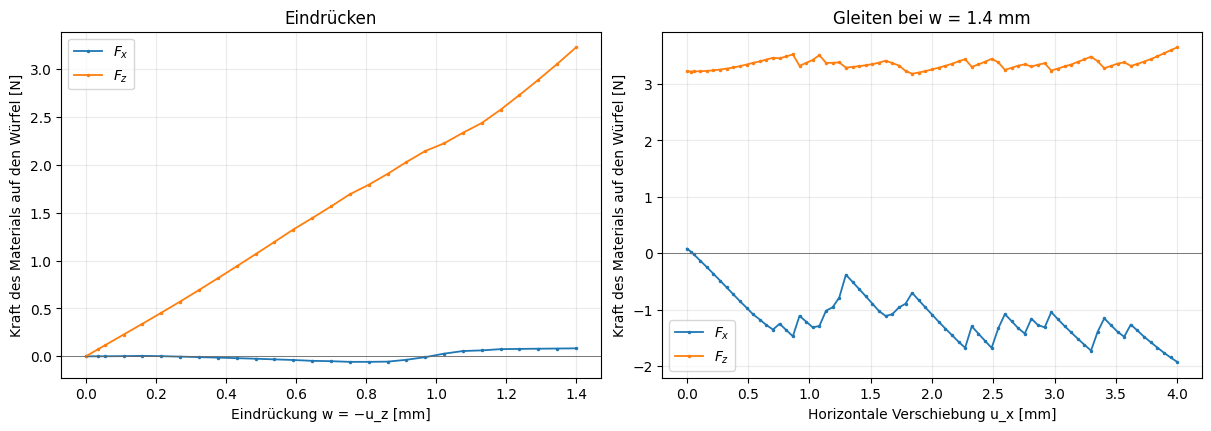

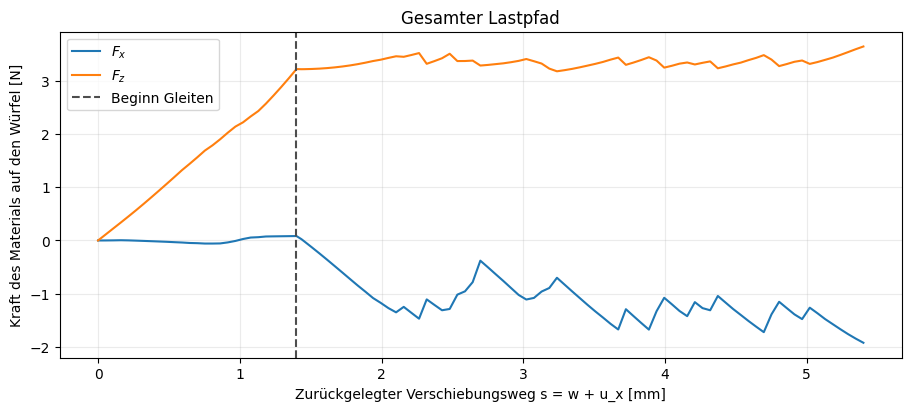

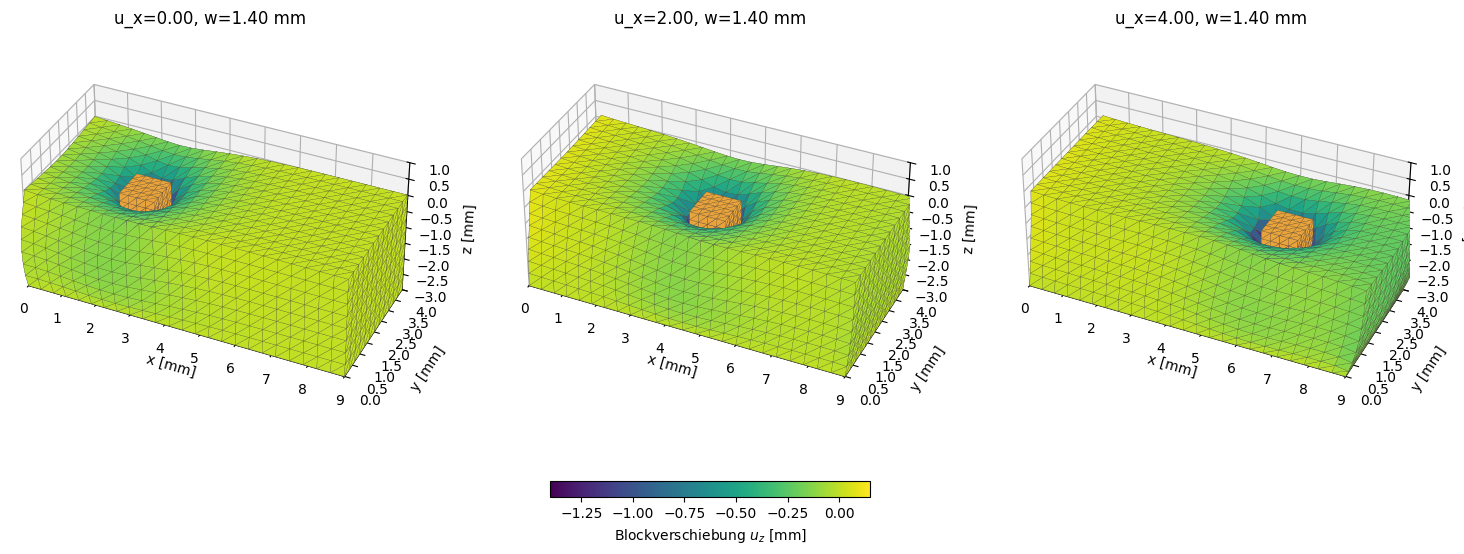

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)
indent = load_history[:, 0] <= indentation_goal+1e-10
slide = load_history[:, 0] >= indentation_goal-1e-10
for ax, mask, abscissa, title, xlabel in (
    (axes[0], indent, -load_history[:, 2], "Eindrücken", "Eindrückung w = −u_z [mm]"),
    (axes[1], slide, load_history[:, 1], "Gleiten bei w = 1.4 mm", "Horizontale Verschiebung u_x [mm]"),
):
    ax.plot(abscissa[mask], load_history[mask, 3], ".-", ms=3, lw=1.3, label="$F_x$")
    ax.plot(abscissa[mask], load_history[mask, 5], ".-", ms=3, lw=1.3, label="$F_z$")
    ax.set(xlabel=xlabel, ylabel="Kraft des Materials auf den Würfel [N]", title=title)
    ax.axhline(0, color="0.4", lw=.6)
    ax.grid(alpha=.25)
    ax.legend()
fig.savefig(results / "ironing_cube_reaction_forces.png", dpi=180)
fig.savefig(results / "ironing_cube_reaction_forces.pdf")
plt.show()

fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
ax.plot(load_history[:, 0], load_history[:, 3], label="$F_x$")
ax.plot(load_history[:, 0], load_history[:, 5], label="$F_z$")
ax.axvline(indentation_goal, color="0.3", ls="--", label="Beginn Gleiten")
ax.set(xlabel="Zurückgelegter Verschiebungsweg s = w + u_x [mm]",
       ylabel="Kraft des Materials auf den Würfel [N]", title="Gesamter Lastpfad")
ax.grid(alpha=.25)
ax.legend()
fig.savefig(results / "ironing_cube_load_path.png", dpi=180)
plt.show()

surface_nodes, surface_cells = boundary_triangles(exterior)
base_surface = cell_tags.values[surface_cells] == BLOCK
cube_surface = ~base_surface
fig = plt.figure(figsize=(15, 5.5), constrained_layout=True)
for k, (s, positions) in enumerate(snapshots[1:]):
    ax = fig.add_subplot(1, len(snapshots)-1, k+1, projection="3d")
    # Eine gemeinsame Collection sortiert Block und Würfel dreiecksweise nach Tiefe.
    # Getrennte Collections würden den eingedrückten Würfel fälschlich verdecken.
    uz = (positions-X)[surface_nodes, 2].mean(axis=1)
    colors = plt.get_cmap("viridis")(plt.Normalize(-indentation_goal, .15)(uz))
    colors[cube_surface] = [233/255, 163/255, 59/255, 1.0]
    ax.add_collection3d(Poly3DCollection(positions[surface_nodes], facecolors=colors,
                                       edgecolors="0.25", linewidths=.15))
    ux, w = prescribed(s)
    ax.set(xlim=(0, block_length), ylim=(0, block_width), zlim=(-block_height, cube_edge),
           xlabel="x [mm]", ylabel="y [mm]", zlabel="z [mm]", title=f"u_x={ux:.2f}, w={w:.2f} mm")
    ax.set_box_aspect((block_length, block_width, block_height+cube_edge))
    ax.view_init(elev=35, azim=-65)
fig.colorbar(plt.cm.ScalarMappable(norm=plt.Normalize(-indentation_goal, .15), cmap="viridis"),
             ax=fig.axes, orientation="horizontal", shrink=.65, pad=.12, fraction=.04, label="Blockverschiebung $u_z$ [mm]")
fig.savefig(results / "ironing_cube_deformation.png", dpi=180)
plt.show()


In [10]:
contact_records = []
projections = project_pairs(all_pairs)
for (slave, igp), (_, _, gap) in zip(all_pairs, projections):
    triangle = x_current[slave_nodes[slave]]
    jac = np.linalg.norm(np.cross(triangle[1]-triangle[0], triangle[2]-triangle[0]))
    contact_records.append([*(gauss_N[igp] @ triangle), gap,
                            -penalty_eps*min(gap, 0), gauss_w[igp]*jac])
np.savetxt(results / "contact_gauss_points.csv", contact_records, delimiter=",", comments="",
           header="x_mm,y_mm,z_mm,gap_mm,p_penalty_MPa,area_weight_mm2")
summary = dict(
    source="Popp et al. (2010), section 8.2, Figure 11, doi:10.1002/nme.2866",
    method="Fischer-Wriggers surface penalty, current configuration, consistent 3D tangent",
    force_convention="force of material on cube = negative top Dirichlet reaction",
    complete=bool(np.isclose(path, path_goal)),
    indentation_mm=indentation_goal, sliding_mm=sliding_goal,
    E_cube_MPa=E_cube, E_block_MPa=E_block, nu=nu,
    elements_T4=len(cell_indices), dofs=len(uh.x.array),
    mesh_counts=[n_block_x, n_block_y, n_block_z, n_cube], penalty_N_per_mm3=penalty_eps,
    contact_gauss_points_per_FE_face=num_gauss, active_set_mode=active_set_mode,
    accepted_increments=len(load_history)-1, cutbacks=cutbacks,
    xdmf_states=len(output_paths), output_intervals=n_output_intervals,
    final_Fx_N=float(load_history[-1, 3]), final_Fz_N=float(load_history[-1, 5]),
    max_residual_N=float(load_history[:, 12].max()), min_detF_path=float(load_history[:, 13].min()),
    max_penetration_mm=float(load_history[:, 19].max()),
    force_balance_relative_max=float(load_history[:, 17].max()),
    contact_balance_relative_max=float(load_history[:, 18].max()),
    local_tangent_checks=local_tangent_checks, global_tangent_errors=global_tangent_errors)
(results / "summary.json").write_text(json.dumps(summary, indent=2)+"\n")
print(json.dumps(summary, indent=2))


{
  "source": "Popp et al. (2010), section 8.2, Figure 11, doi:10.1002/nme.2866",
  "method": "Fischer-Wriggers surface penalty, current configuration, consistent 3D tangent",
  "force_convention": "force of material on cube = negative top Dirichlet reaction",
  "complete": true,
  "indentation_mm": 1.4,
  "sliding_mm": 4.0,
  "E_cube_MPa": 1000.0,
  "E_block_MPa": 1.0,
  "nu": 0.3,
  "elements_T4": 14208,
  "dofs": 9150,
  "mesh_counts": [
    24,
    12,
    8,
    4
  ],
  "penalty_N_per_mm3": 400.0,
  "contact_gauss_points_per_FE_face": 12,
  "active_set_mode": "newton",
  "accepted_increments": 102,
  "cutbacks": 0,
  "xdmf_states": 101,
  "output_intervals": 100,
  "final_Fx_N": -1.924320833958397,
  "final_Fz_N": 3.6496928993222197,
  "max_residual_N": 9.497612486902073e-08,
  "min_detF_path": 0.14363175413679916,
  "max_penetration_mm": 0.09847633322467761,
  "force_balance_relative_max": 3.940802514703656e-09,
  "contact_balance_relative_max": 6.338161310709697e-08,
  "local_t

Alle Ausgaben stehen in `results_ironing_cube`: Kraftplots als PNG/PDF, `load_history.csv` (Verschiebungen, Kräfte mit Vorzeichen, Konvergenz- und Bilanzprüfungen), `summary.json`, Kontakt-Gaußpunkte und 101 vollständige, konvergierte Verschiebungsfelder als XDMF/HDF5. Die XDMF-Zeit ist der Pfadparameter $s$ in mm; exportiert werden 101 Zustände über den gesamten Lastpfad, einschließlich Anfang, Phasenwechsel und Ende. `n_output_intervals` steuert die Anzahl (Intervalle + 1). Die drei Deformationsabbildungen verwenden weiterhin ausgewählte Zustände. Bei nicht konvergiertem Lastpfad wird mit einer Fehlermeldung abgebrochen; bis dahin gespeicherte Zustände sind nur Teilergebnisse.

`checkpoint.npz` speichert den letzten konvergierten Zustand, die gesamte Kraftgeschichte, alle bislang erreichten XDMF-Ausgabezustände, die Bildzustände und die Modellparameter. Standardmäßig wird ein vorhandener Checkpoint automatisch verwendet. `resume_from_checkpoint=True` setzt nach Prüfung von Parametern, Netz und Gleichgewicht fort. Für einen unabhängigen Lauf von $s=0$ ist `resume_from_checkpoint=False` einzustellen.


Die Kennzahlen der aktuellen Rechnung stehen oben und in `summary.json`. Gute Solverkonvergenz ersetzt keine Diskretisierungsprüfung: Insbesondere die Schwankungen von $F_x$ und die endliche Durchdringung müssen für quantitative Vergleiche durch Netz-, Integrations- und Penalty-Verfeinerung untersucht werden.
